In [22]:
import pandas as pd
from pathlib import Path
import sys
import inspect
import importlib
import numpy as np

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
from src.profile_trainer import run_profile_training_experiment

In [28]:
path = r"C:\Data_analysis\Thesis\Data\03_Training\Imputed_data\15_min\df_BU_TotActPwr_Academy.parquet"
df_imputed = pd.read_parquet(path)


In [29]:


target_col = "BU_TotActPwr_Academy"

feature_cols = [c for c in df_imputed.columns if c != target_col]

results_df, horizon_results = run_profile_training_experiment(
    df=df_imputed,
    target_col=target_col,
    feature_cols=feature_cols,
    dataset_name="15min_profile_dataset",
    output_dir="artifacts/profile_forecasting",
    horizon_steps=96,
    issue_hour=23,
    issue_minute=45,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    selected_models=["multi_ridge", "multi_random_forest", "multi_xgboost"],
    drop_feature_nan=False,
)

results_df

Training multi_ridge for day-ahead profile forecasting: BU_TotActPwr_Academy
Training multi_random_forest for day-ahead profile forecasting: BU_TotActPwr_Academy
Training multi_xgboost for day-ahead profile forecasting: BU_TotActPwr_Academy


,timestamp,task_type,dataset_name,target,model_name,model_params,n_features,n_horizons,n_train_days,n_val_days,...,val_MAPE,val_sMAPE,val_R2,test_MAE,test_RMSE,test_MAPE,test_sMAPE,test_R2,prediction_path,horizon_metrics_path
0,2026-04-01 15:11:45,day_ahead_profile_forecasting,15min_profile_dataset,BU_TotActPwr_Academy,multi_ridge,"{""estimator__alpha"": 1.0, ""estimator__copy_X"":...",38,96,77,16,...,29.302867,24.573377,0.696291,2.108500,3.362267,22.691000,21.939780,0.789716,artifacts\profile_forecasting\predictions\mult...,artifacts\profile_forecasting\horizon_metrics\...
1,2026-04-01 15:11:46,day_ahead_profile_forecasting,15min_profile_dataset,BU_TotActPwr_Academy,multi_random_forest,"{""estimator__bootstrap"": true, ""estimator__ccp...",38,96,77,16,...,25.541352,22.568083,0.708349,2.258453,3.844697,20.709556,21.124733,0.725042,artifacts\profile_forecasting\predictions\mult...,artifacts\profile_forecasting\horizon_metrics\...
2,2026-04-01 15:12:47,day_ahead_profile_forecasting,15min_profile_dataset,BU_TotActPwr_Academy,multi_xgboost,"{""estimator__objective"": ""reg:squarederror"", ""...",38,96,77,16,...,23.668712,21.722331,0.735772,2.194764,3.709358,20.217784,20.738223,0.744059,artifacts\profile_forecasting\predictions\mult...,artifacts\profile_forecasting\horizon_metrics\...


In [30]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_profile_day(prediction_csv_path, row_idx=0, title=None):
    df = pd.read_csv(prediction_csv_path, index_col=0, parse_dates=True)

    true_cols = [c for c in df.columns if c.endswith("_true")]
    pred_cols = [c for c in df.columns if c.endswith("_pred")]

    true_vals = df.iloc[row_idx][true_cols].values.astype(float)
    pred_vals = df.iloc[row_idx][pred_cols].values.astype(float)

    issue_time = df.index[row_idx]

    plt.figure(figsize=(14, 5))
    plt.plot(true_vals, label="Actual")
    plt.plot(pred_vals, label="Predicted")
    plt.xlabel("15-minute step of next day")
    plt.ylabel("Load / Power")
    plt.title(title or f"Day-ahead profile forecast\nIssue time: {issue_time}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

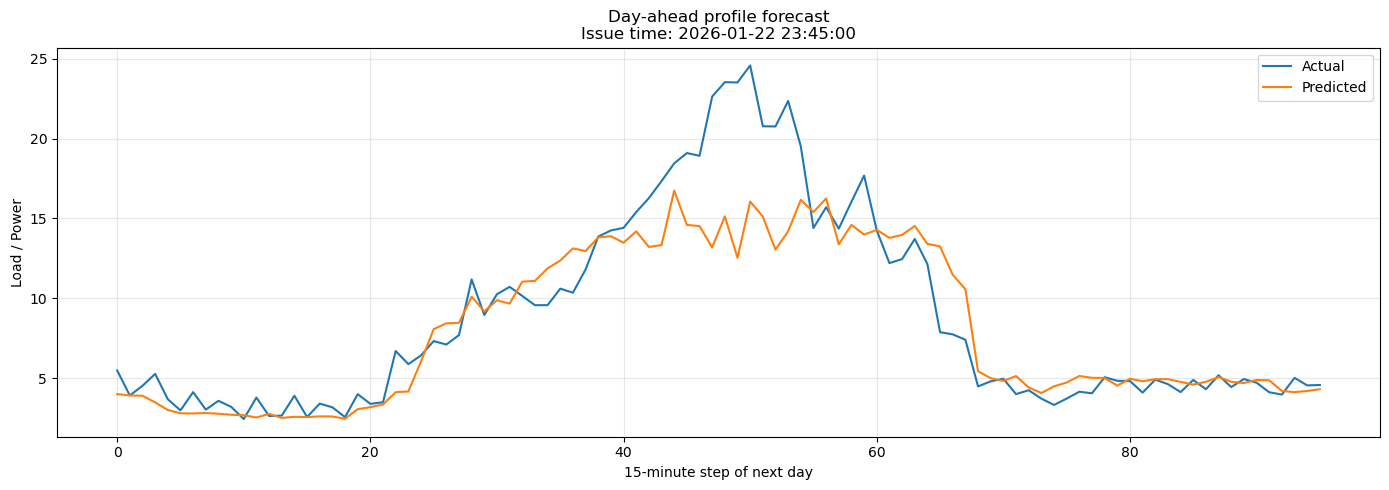

In [36]:
prediction_csv_path = r"C:\Data_analysis\Thesis\JupyterNotebooks\artifacts\profile_forecasting\predictions\multi_random_forest_BU_TotActPwr_Academy_profile_predictions.csv"
plot_profile_day(prediction_csv_path, row_idx=0)

In [37]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_multiple_profile_days(prediction_csv_path, row_indices=(0, 1, 2)):
    df = pd.read_csv(prediction_csv_path, index_col=0, parse_dates=True)

    true_cols = [c for c in df.columns if c.endswith("_true")]
    pred_cols = [c for c in df.columns if c.endswith("_pred")]

    for row_idx in row_indices:
        true_vals = df.iloc[row_idx][true_cols].values.astype(float)
        pred_vals = df.iloc[row_idx][pred_cols].values.astype(float)
        issue_time = df.index[row_idx]

        plt.figure(figsize=(14, 5))
        plt.plot(true_vals, label="Actual")
        plt.plot(pred_vals, label="Predicted")
        plt.xlabel("15-minute step of next day")
        plt.ylabel("Load / Power")
        plt.title(f"Day-ahead profile forecast\nIssue time: {issue_time}")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

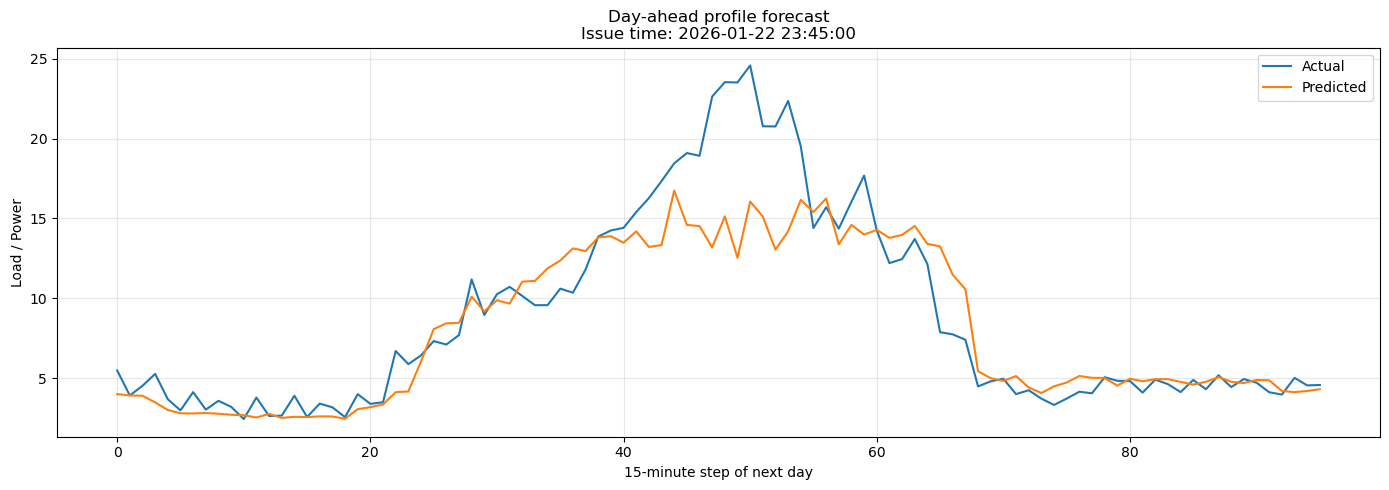

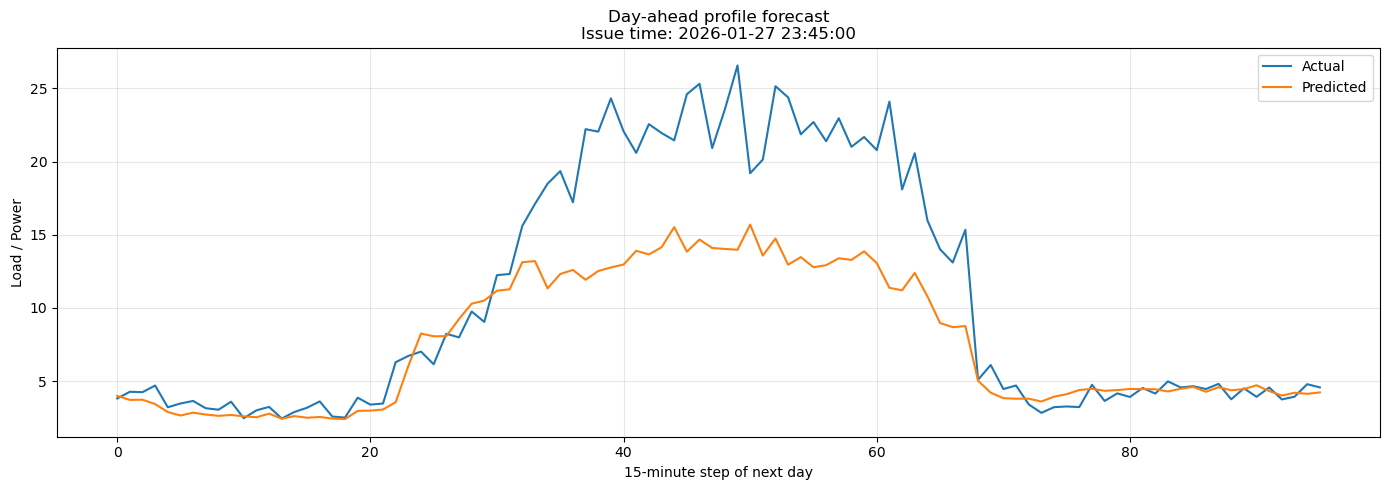

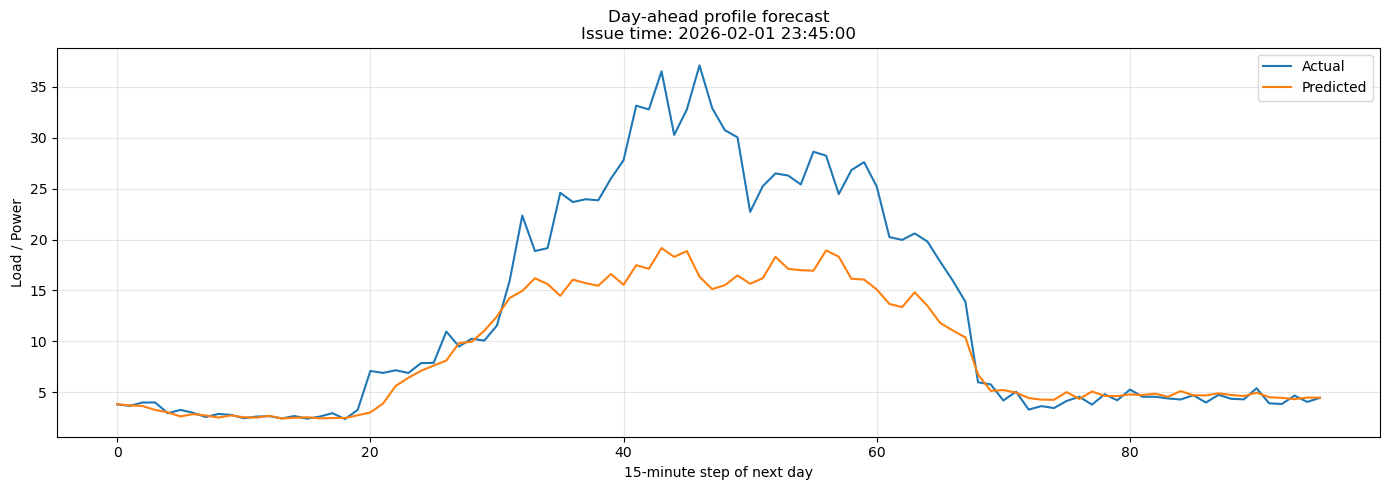

In [38]:
plot_multiple_profile_days(
    prediction_csv_path,
    row_indices=(0, 5, 10)
)

In [34]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_average_profile(prediction_csv_path, title="Average day-ahead profile"):
    df = pd.read_csv(prediction_csv_path, index_col=0, parse_dates=True)

    true_cols = [c for c in df.columns if c.endswith("_true")]
    pred_cols = [c for c in df.columns if c.endswith("_pred")]

    true_mean = df[true_cols].mean(axis=0).values.astype(float)
    pred_mean = df[pred_cols].mean(axis=0).values.astype(float)

    plt.figure(figsize=(14, 5))
    plt.plot(true_mean, label="Average Actual")
    plt.plot(pred_mean, label="Average Predicted")
    plt.xlabel("15-minute step of next day")
    plt.ylabel("Load / Power")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

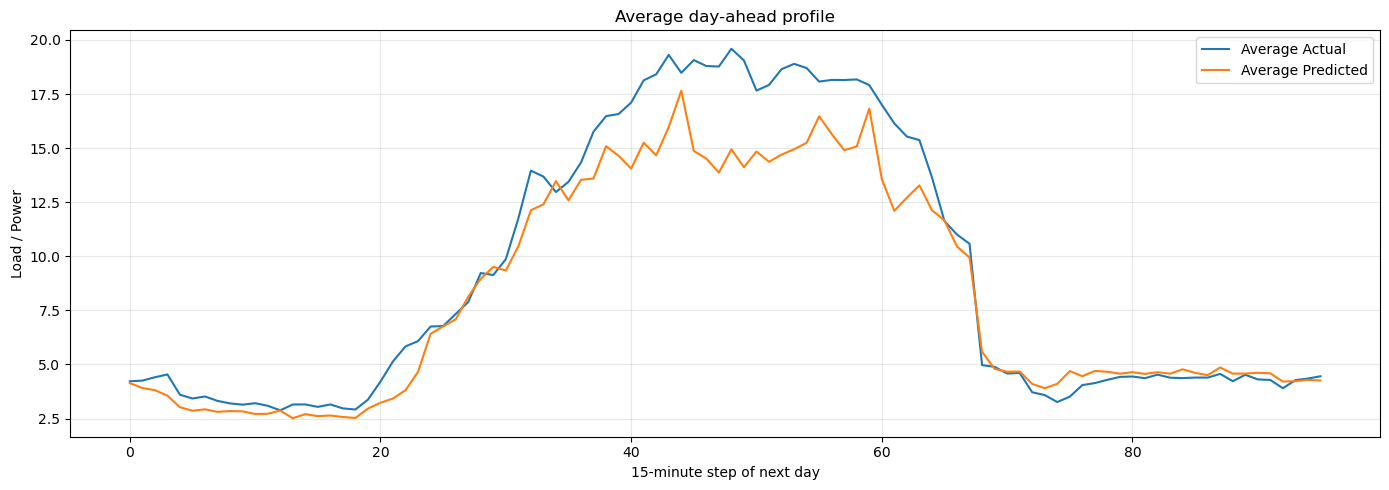

In [35]:
plot_average_profile(prediction_csv_path)

In [39]:
import pandas as pd
import numpy as np


def load_profile_predictions_as_timeseries(prediction_csv_path: str) -> pd.DataFrame:
    """
    Convert saved wide-format profile prediction CSV into long time-series format.

    Input wide format:
        index = forecast issue time
        columns = y_tplus_001_true ... y_tplus_096_true
                  y_tplus_001_pred ... y_tplus_096_pred

    Output long format:
        index = forecasted timestamps
        columns = actual, predicted, residual, issue_time, step
    """
    df = pd.read_csv(prediction_csv_path, index_col=0, parse_dates=True)

    true_cols = sorted([c for c in df.columns if c.endswith("_true")])
    pred_cols = sorted([c for c in df.columns if c.endswith("_pred")])

    if len(true_cols) != len(pred_cols):
        raise ValueError("Mismatch between number of true and predicted columns.")

    records = []

    for issue_time, row in df.iterrows():
        for i, (t_col, p_col) in enumerate(zip(true_cols, pred_cols), start=1):
            forecast_time = issue_time + pd.Timedelta(minutes=15 * i)

            actual = float(row[t_col])
            predicted = float(row[p_col])

            records.append({
                "forecast_time": forecast_time,
                "issue_time": issue_time,
                "step": i,
                "actual": actual,
                "predicted": predicted,
                "residual": actual - predicted,
                "abs_error": abs(actual - predicted),
            })

    ts_df = pd.DataFrame(records).sort_values("forecast_time")
    ts_df = ts_df.set_index("forecast_time")

    return ts_df

In [40]:
import matplotlib.pyplot as plt


def plot_profile_diagnostics(
    prediction_csv_path: str,
    model_name: str = "profile_model",
    target_name: str = "target",
    dataset_name: str = "dataset",
    zoom_start: str | None = None,
    zoom_end: str | None = None,
    figsize=(16, 16),
):
    """
    Create a 4-panel diagnostic plot similar to your screenshot:
    1. Actual vs Predicted over time
    2. Residuals over time
    3. Zoomed window
    4. Actual vs Predicted scatter
    """
    ts_df = load_profile_predictions_as_timeseries(prediction_csv_path)

    if zoom_start is None:
        zoom_start = str(ts_df.index.min())
    if zoom_end is None:
        zoom_end = str(min(ts_df.index.min() + pd.Timedelta(days=3), ts_df.index.max()))

    zoom_df = ts_df.loc[zoom_start:zoom_end].copy()

    fig, axes = plt.subplots(4, 1, figsize=figsize)

    title_prefix = f"{model_name} - {target_name} [{dataset_name}]"

    # 1. Actual vs predicted over time
    axes[0].plot(ts_df.index, ts_df["actual"], label="Actual")
    axes[0].plot(ts_df.index, ts_df["predicted"], label="Predicted")
    axes[0].set_title(title_prefix)
    axes[0].set_ylabel(f"{target_name} [kW]")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # 2. Residuals over time
    axes[1].plot(ts_df.index, ts_df["residual"])
    axes[1].axhline(0, linestyle="--")
    axes[1].set_title(f"{title_prefix} - Residuals Over Time")
    axes[1].set_ylabel("Residual [kW]")
    axes[1].grid(True, alpha=0.3)

    # 3. Zoomed window
    axes[2].plot(zoom_df.index, zoom_df["actual"], label="Actual")
    axes[2].plot(zoom_df.index, zoom_df["predicted"], label="Predicted")
    axes[2].set_title(f"{title_prefix} - Zoomed Window")
    axes[2].set_ylabel(f"{target_name} [kW]")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    # 4. Scatter
    axes[3].scatter(ts_df["actual"], ts_df["predicted"], alpha=0.5)
    min_val = min(ts_df["actual"].min(), ts_df["predicted"].min())
    max_val = max(ts_df["actual"].max(), ts_df["predicted"].max())
    axes[3].plot([min_val, max_val], [min_val, max_val], linestyle="--")
    axes[3].set_title(f"{title_prefix} - Actual vs Predicted Scatter")
    axes[3].set_xlabel("Actual [kW]")
    axes[3].set_ylabel("Predicted [kW]")
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

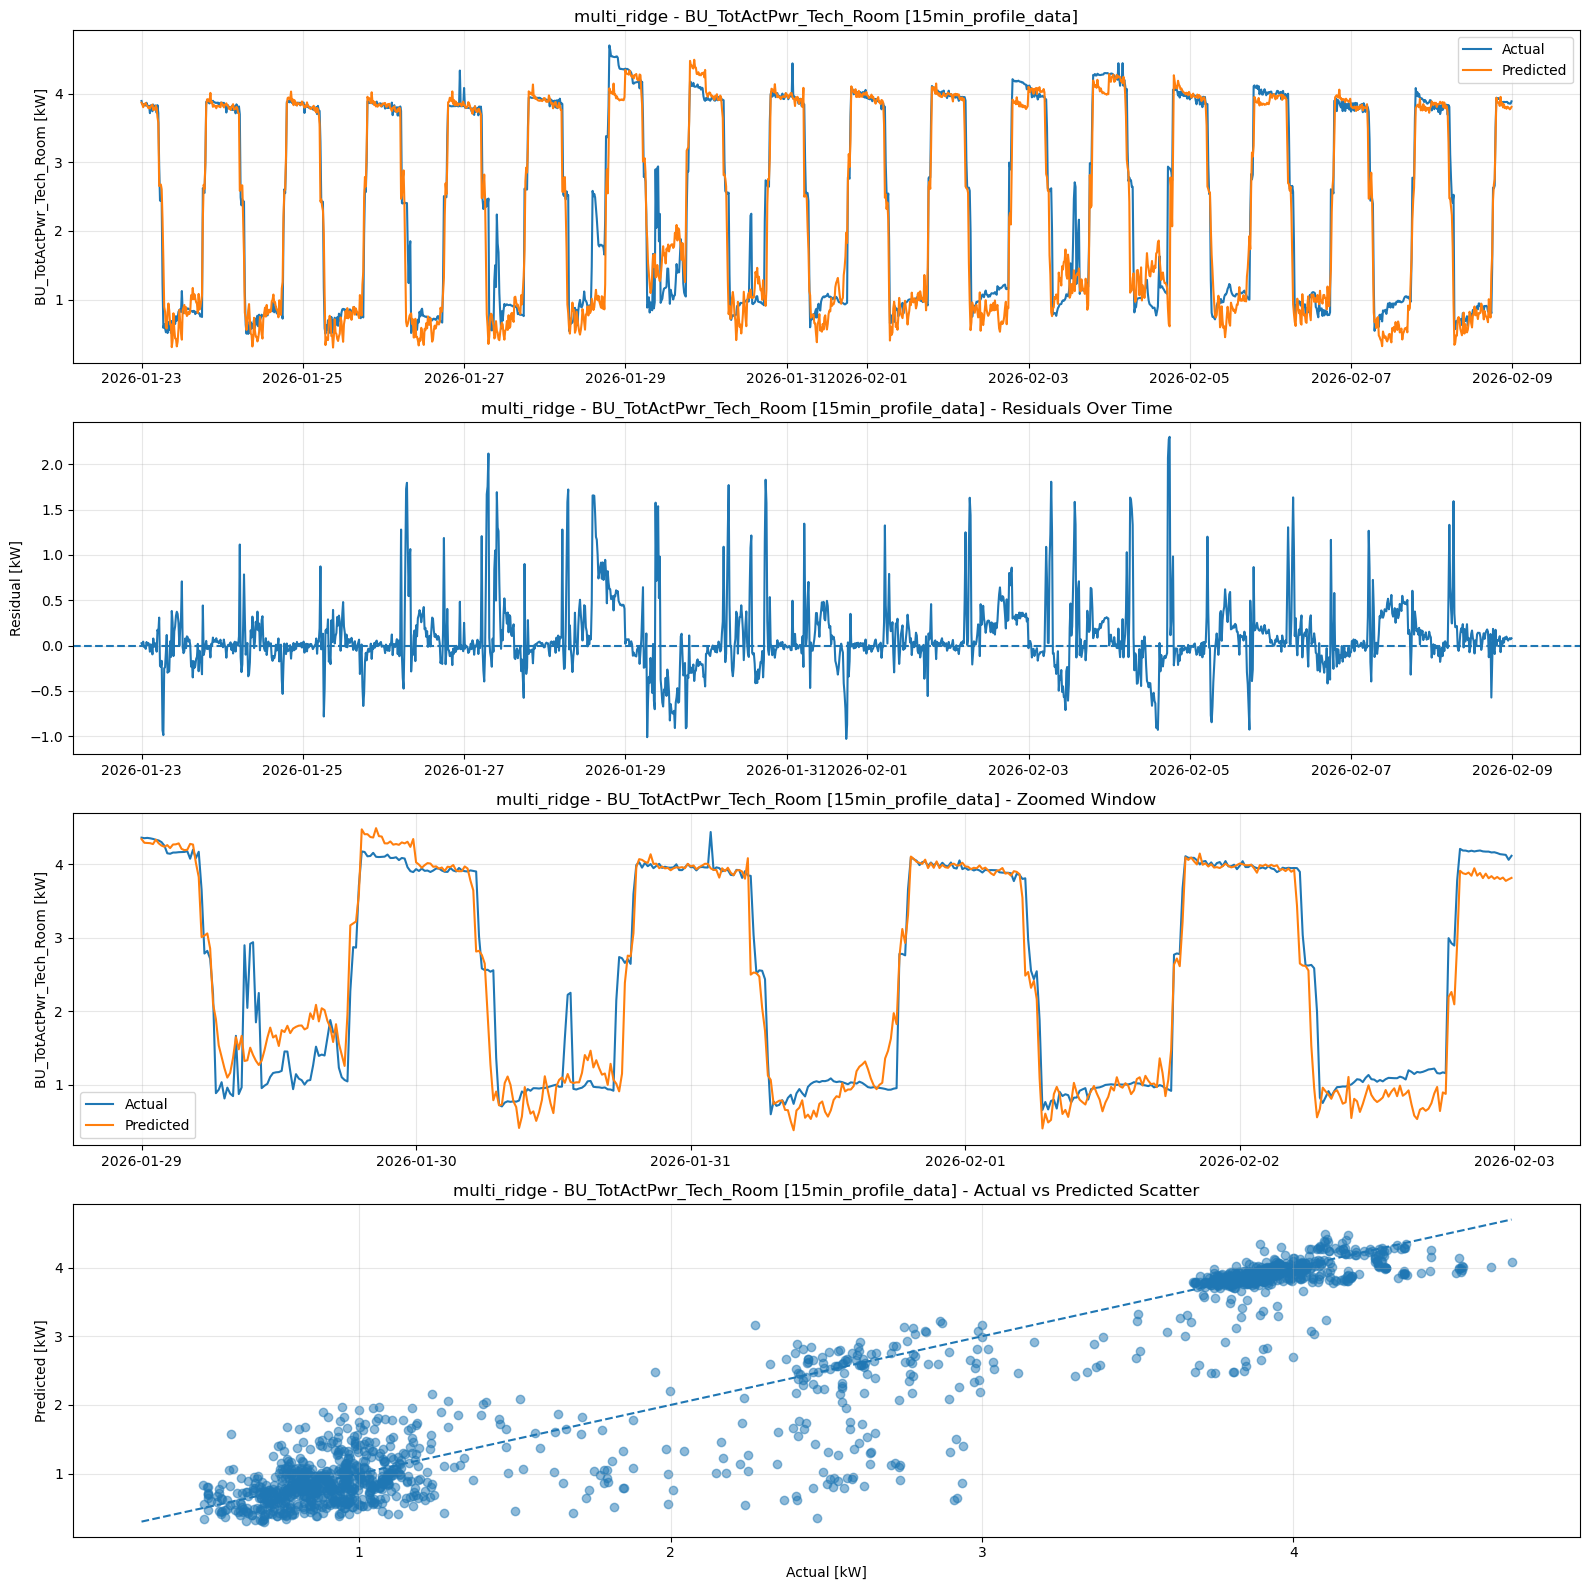

In [43]:
prediction_csv_path = r"C:\Data_analysis\Thesis\JupyterNotebooks\artifacts/profile_forecasting/predictions/multi_ridge_BU_TotActPwr_Tech_Room_profile_predictions.csv"

plot_profile_diagnostics(
    prediction_csv_path=prediction_csv_path,
    model_name="multi_ridge",
    target_name="BU_TotActPwr_Tech_Room",
    dataset_name="15min_profile_data",
    zoom_start="2026-01-29",
    zoom_end="2026-02-02",
)

In [1]:

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch version:", torch.__version__)
print("Device:", device)


Torch version: 2.3.1
Device: cpu
